<a href="https://colab.research.google.com/github/WaRdenLF/week3_lab/blob/main/Lab_Data_Exploration_and_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSE206 Fundamental of Machine Learning
## Lab: Exploring, Visualising and Cleaning Data

**Duration:** 2 hours

| Session | What happens | Dataset | Time |
|---|---|---|---|
| Session 1 | Guided walkthrough with the instructor | Titanic passengers | 60 min |
| Session 2 | Graded exercises, done on your own | Palmer penguins | 60 min, 100 marks |

### What you will learn today

1. Load a CSV file into Python with **pandas**.
2. Explore the data: size, columns, data types, summaries and missing values.
3. Draw a **histogram**, a **bar chart**, a **scatter plot** and a **heatmap of missing values**, and label the axes and the data.
4. Clean the data: remove columns, insert new columns and fill missing values.
5. Prepare the data for machine learning: choose the output column, turn text into numbers and scale the numbers.

---
# Session 1: Guided Walkthrough

| Part | Topic | Time |
|---|---|---|
| Part 1 | Loading and exploring data | 20 min |
| Part 2 | Visualising data | 15 min |
| Part 3 | Cleaning and preparing data | 25 min |

## Step 0: Import the libraries

A **library** is a set of ready-made tools. We give each library a short nickname so we type less. Google Colab already has all three installed.

| Library | Nickname | What we use it for |
|---|---|---|
| pandas | `pd` | Reading and working with tables of data |
| matplotlib.pyplot | `plt` | Drawing charts |
| seaborn | `sns` | Drawing nicer charts with less code |

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## About the dataset

The Titanic ship sank in 1912. The file has one row for each of 891 passengers.

| Column | Meaning |
|---|---|
| survived | 1 = survived, 0 = did not survive |
| pclass | Ticket class: 1, 2 or 3 |
| sex | male or female |
| age | Age in years |
| sibsp | Number of brothers, sisters or husband/wife on board |
| parch | Number of parents or children on board |
| fare | Ticket price |
| embarked | Port where the passenger got on: S, C or Q |
| class | Ticket class as a word: First, Second, Third |
| who | man, woman or child |
| adult_male | True or False |
| deck | Deck letter of the cabin |
| embark_town | Port name: Southampton, Cherbourg, Queenstown |
| alive | yes or no |
| alone | True if travelling alone |

---
# Part 1: Loading and Exploring Data

## 1.1 Read the CSV file

A **CSV** (comma-separated values) file is a simple text table. Each line is a row, and commas separate the columns.

`pd.read_csv()` reads the file and gives us a **DataFrame**, which is a table with rows and columns. We call it `df`.

Here we read the file straight from the internet, so you do not need to download anything.

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")

print("Data loaded.")

## 1.2 First look at the data

`head()` shows the first 5 rows. `tail()` shows the last rows. You can put a number inside the brackets.

In [ ]:
df.head()

In [ ]:
df.tail(3)

`shape` gives the size of the table as **(rows, columns)**. There are no brackets after `shape`.

In [ ]:
df.shape

In [ ]:
df.columns

`info()` shows each column, how many values are **not empty**, and the **data type**:

- `int64` = whole numbers
- `float64` = decimal numbers
- `object` = text
- `bool` = True / False

Look at the **Non-Null Count**. The table has 891 rows, so a column with fewer than 891 has missing values.

In [ ]:
df.info()

`describe()` gives a quick summary of every numeric column:

| Row | Meaning |
|---|---|
| count | How many values are not empty |
| mean | Average |
| std | Standard deviation (how spread out the values are) |
| min / max | Smallest / largest value |
| 50% | Median (the middle value) |

In [ ]:
df.describe()

## 1.3 Selecting columns and rows

| What we want | Code |
|---|---|
| One column | `df["age"]` |
| Several columns | `df[["age", "fare"]]` (note the double brackets) |
| Rows that match a condition | `df[df["age"] < 10]` |

In [ ]:
df["age"].head()

In [ ]:
df[["sex", "age", "fare"]].head()

In [ ]:
children = df[df["age"] < 10]
print("Number of children under 10:", len(children))

## 1.4 Counting and grouping

`value_counts()` counts how many times each value appears in a column.

In [ ]:
df["class"].value_counts()

`groupby()` splits the rows into groups and calculates something for each group.

Because `survived` is 0 or 1, its **mean** is the survival rate. For example, 0.74 means 74% survived.

In [ ]:
df.groupby("sex")["survived"].mean()

## 1.5 Find the missing values

An empty cell is shown as `NaN` ("Not a Number"). You can see some in the `age` and `deck` columns of `df.head()`.

`isnull()` marks every empty cell as True. `sum()` then counts them for each column.

In [ ]:
df.isnull().sum()

### Heatmap of missing values

Numbers are useful, but a picture shows the missing values faster. A **heatmap** colours every cell of the table:

- **Dark** = the value is there
- **Yellow** = the value is missing

Each row of the picture is one passenger, and each column of the picture is one column of the table.

- `cbar=False` hides the colour bar at the side.
- `yticklabels=False` hides the 891 row numbers, which would be too crowded to read.

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values in the Titanic Data (yellow = missing)")
plt.xlabel("Column")
plt.ylabel("Passengers")
plt.show()

**What we learn:**

- `deck` is almost all yellow: most of it is missing (688 of 891).
- `age` has many yellow lines: 177 values are missing.
- `embarked` and `embark_town` have only 2 missing values, so you see just one thin line.
- All the other columns are complete.

We will fix these in Part 3.

---
# Part 2: Visualising Data

A chart is easy to read only when it is **labelled**. Every chart should have:

1. A **title**: `plt.title("...")`
2. An **x-axis label** (the bottom): `plt.xlabel("...")`
3. A **y-axis label** (the side): `plt.ylabel("...")`
4. **Data labels** where they help, such as the number on top of each bar

Most charts follow the same pattern:

```python
plt.figure(figsize=(8, 5))   # create an empty chart, 8 wide and 5 tall
# ... draw the chart ...
plt.title("...")
plt.xlabel("...")
plt.ylabel("...")
plt.show()                   # display it
```

## 2.1 Histogram

A **histogram** shows how **one numeric column** is spread out. The values are split into ranges called **bins**, and the height of each bar is how many values fall in that range.

`dropna()` leaves out the missing ages.

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=20)
plt.title("Age of Titanic Passengers")
plt.xlabel("Age (years)")
plt.ylabel("Number of passengers")
plt.show()

**How to read it:** most passengers were between 20 and 40 years old, and there was a small group of young children.

The same chart with **Seaborn**. Seaborn leaves out missing values by itself.

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df["age"], bins=20)
plt.title("Age of Titanic Passengers")
plt.xlabel("Age (years)")
plt.ylabel("Number of passengers")
plt.show()

## 2.2 Bar chart

A **bar chart** compares **categories**, for example how many passengers were in each class.

**Histogram or bar chart?**

- Histogram: numbers split into ranges (age 0-10, 10-20, ...).
- Bar chart: separate categories (First, Second, Third).

We first count the passengers in each class, then draw one bar for each class.
`plt.bar_label(bars)` writes the number on top of each bar. This is how we **label the data**.

In [ ]:
class_counts = df["class"].value_counts()
print(class_counts)

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.index, class_counts.values)
plt.bar_label(bars)
plt.title("Number of Passengers in Each Class")
plt.xlabel("Ticket class")
plt.ylabel("Number of passengers")
plt.show()

With **Seaborn**, `countplot()` does the counting for us.

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="class")
plt.title("Number of Passengers in Each Class")
plt.xlabel("Ticket class")
plt.ylabel("Number of passengers")
plt.show()

## 2.3 Scatter plot

A **scatter plot** shows the relationship between **two numeric columns**. Each dot is one passenger.

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["age"], df["fare"])
plt.title("Age vs Ticket Fare")
plt.xlabel("Age (years)")
plt.ylabel("Fare paid")
plt.show()

With **Seaborn** we can colour the dots by a category using `hue=`. Here the colour shows whether the passenger survived.

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="fare", hue="alive")
plt.title("Age vs Ticket Fare, Coloured by Survival")
plt.xlabel("Age (years)")
plt.ylabel("Fare paid")
plt.show()

**What we learn:** most passengers paid a low fare. Passengers who paid a high fare were more often survivors.

### Which chart should I use?

| Question you want to answer | Chart |
|---|---|
| How is one numeric column spread out? | Histogram |
| How do categories compare? | Bar chart |
| How are two numeric columns related? | Scatter plot |
| Where are the missing values? | Heatmap of `df.isnull()` |

---
# Part 3: Cleaning and Preparing Data

Machine learning models need **clean numbers**. They cannot work with:

- empty cells (missing values),
- text such as "male" and "female",
- columns on very different scales (age goes up to 80, fare goes up to 512).

In this part we fix all three. First we keep an untouched copy of the original data, in case we need it later.

In [ ]:
df_original = df.copy()

## 3.1 Remove columns

Some columns repeat information we already have, and one is mostly empty. We remove them with `drop(columns=[...])`.

| Column | Why we remove it |
|---|---|
| class | Same as `pclass` |
| alive | Same as `survived` |
| embark_town | Same as `embarked` |
| who, adult_male | Can be worked out from `sex` and `age` |
| alone | Can be worked out from `sibsp` and `parch` |
| deck | 688 of 891 values are missing |

In [ ]:
df = df.drop(columns=["class", "alive", "embark_town", "who", "adult_male", "alone", "deck"])

print("New shape:", df.shape)
df.head()

## 3.2 Insert new columns

**Way 1:** write a new column name and give it a value. The new column is added at the **end**.

Here we create `family_size` = brothers/sisters/spouse + parents/children + the passenger themself.

In [ ]:
df["family_size"] = df["sibsp"] + df["parch"] + 1
df.head()

## 3.3 Fill missing values

There are two main choices:

| Choice | Code | When to use |
|---|---|---|
| Delete rows with missing values | `df.dropna()` | Only a few rows are missing |
| Fill the gap with a value | `df["col"].fillna(value)` | We do not want to lose rows |

`age` has 177 missing values. That is 20% of the passengers, too many to delete, so we fill the gaps.

Common fill values:

- **Numeric column:** the **median** (the middle value). The median is better than the mean because a few very large values do not pull it up.
- **Text column:** the **mode** (the most frequent value). `mode()` can return more than one value, so `[0]` takes the first one.

In [ ]:
median_age = df["age"].median()
print("Median age:", median_age)

df["age"] = df["age"].fillna(median_age)

In [ ]:
most_common_port = df["embarked"].mode()[0]
print("Most common port:", most_common_port)

df["embarked"] = df["embarked"].fillna(most_common_port)

Let us check again, with numbers and with the heatmap. There should be no missing values now, so there should be no yellow at all.

In [ ]:
df.isnull().sum()

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values After Cleaning (yellow = missing)")
plt.xlabel("Column")
plt.ylabel("Passengers")
plt.show()

## 3.4 Label the output column

In machine learning we split the columns into two parts:

- **Features (X):** the input columns the model looks at.
- **Target or label (y):** the **output** column we want the model to predict.

Our question is "Did the passenger survive?", so the output column is `survived`.

We remove `survived` from X (the model must not see the answer). We also remove `passenger_id`, because an ID number does not help to predict anything.

In [ ]:
y = df["survived"]
X = df.drop(columns=["survived"])

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

Our output `survived` is already a number (0 or 1). Often the output is **text**, like the original `alive` column ("yes" / "no").

We can turn text labels into numbers with `map()`. We give it a **dictionary** that says which text becomes which number.

In [ ]:
alive_as_number = df_original["alive"].map({"no": 0, "yes": 1})

pd.DataFrame({"alive (text)": df_original["alive"], "alive (number)": alive_as_number}).head()

## 3.5 Encode categorical values (text to numbers)

X still has two text columns: `sex` and `embarked`. Models only understand numbers.

**A column with two categories** (male / female): use `map()` to turn them into 0 and 1.

In [37]:
X["sex"] = X["sex"].map({"male": 0, "female": 1})
X.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,sex,body_mass_kg
0,Torgersen,39.10,18.7,181.0,NaN,3.75
1,Torgersen,39.50,17.4,186.0,NaN,3.80
2,Torgersen,40.30,18.0,195.0,NaN,3.25
3,Torgersen,44.45,17.3,197.0,NaN,4.05
4,Torgersen,36.70,19.3,193.0,NaN,3.45


**A column with three or more categories** (S, C, Q): we should **not** use 0, 1, 2. The numbers would suggest that Q (2) is "bigger" than S (0), which makes no sense for ports.

Instead we use **one-hot encoding**: each category gets its own column with 1 (yes) or 0 (no).

| embarked | | embarked_C | embarked_Q | embarked_S |
|---|---|---|---|---|
| S | becomes | 0 | 0 | 1 |
| C | becomes | 1 | 0 | 0 |
| Q | becomes | 0 | 1 | 0 |

`pd.get_dummies()` does this for us. `dtype=int` gives 0 and 1 instead of False and True.

In [ ]:
X = pd.get_dummies(X, columns=["embarked"], dtype=int)
X.head()

## 3.6 Feature scaling

Look at the ranges: `age` goes from about 0 to 80, but `fare` goes from 0 to 512. Many models would think `fare` is more important just because its numbers are bigger. **Scaling** puts the columns on the same range.

We use **min-max scaling**, which moves every value into the range **0 to 1**:

```
new value = (value - smallest value) / (largest value - smallest value)
```

- The smallest value becomes 0.
- The largest value becomes 1.
- Everything else falls in between.

In [ ]:
print("Before scaling:")
X[["age", "fare"]].describe().round(2)

In [ ]:
X["age"] = (X["age"] - X["age"].min()) / (X["age"].max() - X["age"].min())
X["fare"] = (X["fare"] - X["fare"].min()) / (X["fare"].max() - X["fare"].min())

print("After scaling:")
X[["age", "fare"]].describe().round(2)

Now `min` is 0 and `max` is 1 for both columns.

## 3.7 The data is ready

Let us look at the final table and check the data types. Every column should now be a number, and nothing should be missing.

In [ ]:
X.head()

In [ ]:
X.info()

All columns are numbers, there are no missing values and the large numbers are scaled. In a later lab we will give `X` and `y` to a machine learning model, and we will learn how scikit-learn can do these cleaning steps for us automatically.

## Session 1 Summary

| Task | Code |
|---|---|
| Read a CSV file | `pd.read_csv("file.csv")` |
| First rows / size / column types | `df.head()`, `df.shape`, `df.info()` |
| Summary statistics | `df.describe()` |
| Count values | `df["col"].value_counts()` |
| Group and average | `df.groupby("col")["other"].mean()` |
| Count missing values | `df.isnull().sum()` |
| Heatmap of missing values | `sns.heatmap(df.isnull(), cbar=False)` |
| Histogram | `plt.hist(...)` or `sns.histplot(...)` |
| Bar chart | `plt.bar(...)` or `sns.countplot(...)` |
| Scatter plot | `plt.scatter(...)` or `sns.scatterplot(...)` |
| Label the axes | `plt.title()`, `plt.xlabel()`, `plt.ylabel()` |
| Label the bars | `plt.bar_label(bars)` |
| Remove columns | `df.drop(columns=[...])` |
| Insert a column | `df["new"] = ...` or `df.insert(position, "new", values)` |
| Fill missing values | `df["col"].fillna(value)` |
| Choose the output column | `y = df["target"]`, `X = df.drop(columns=["target"])` |
| Text to numbers (2 categories) | `df["col"].map({"a": 0, "b": 1})` |
| Text to numbers (3+ categories) | `pd.get_dummies(df, columns=["col"], dtype=int)` |
| Min-max scaling | `(x - x.min()) / (x.max() - x.min())` |

---
# Session 2: Graded Exercises (100 marks)

## Instructions

1. Before you start, click **Runtime > Restart session** to clear the Session 1 variables. Then run the cells from Question 1 onwards.
2. Work **on your own**.
3. Write your code in the cells marked `# YOUR CODE HERE`.
4. Write your written answers in the cells that start with **Your answer:** (double-click the cell to edit it).
5. Marks for each part are shown in square brackets, for example **[3 marks]**.
6. Every chart must have a title and axis labels.
7. Before you submit, click **Runtime > Restart session and run all** and check that there are no errors.
8. Rename the file to `CSE206_Lab1_YourName`, then click **File > Download > Download .ipynb** and submit the downloaded file.

The Session 1 walkthrough above is your guide. Most questions use the same code with different column names.

| Part | Topic | Marks |
|---|---|---|
| A | Loading and exploring data | 20 |
| B | Visualising data | 25 |
| C | Cleaning and preparing data | 45 |
| D | Short theory questions | 10 |
| | **Total** | **100** |

## About the dataset

The penguins dataset has measurements of 344 penguins from three islands in Antarctica.

File address:
`https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv`

| Column | Meaning |
|---|---|
| species | Adelie, Chinstrap or Gentoo |
| island | Biscoe, Dream or Torgersen |
| bill_length_mm | Length of the beak (mm) |
| bill_depth_mm | Depth (height) of the beak (mm) |
| flipper_length_mm | Length of the flipper (wing) (mm) |
| body_mass_g | Body weight (grams) |
| sex | MALE or FEMALE |

In this lab, **species** is the output column we want to predict.

---
## Part A: Loading and Exploring Data (20 marks)

### Question 1: Load the data (5 marks)

a) Import pandas, matplotlib.pyplot and seaborn with their usual nicknames. **[1 mark]**

b) Read the penguins CSV file (address given above) into a DataFrame called `df`. **[2 marks]**

c) Show the first 5 rows. **[1 mark]**

d) Show the shape of the table. **[1 mark]**

In [10]:
# YOUR CODE HERE (a) and (b)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# YOUR CODE HERE (c)
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [13]:
# YOUR CODE HERE (d)
print(df.shape)


(344, 7)


### Question 2: Explore the data (10 marks)

a) Show the column names, the number of non-empty values and the data type of every column. *Hint: `info()`* **[2 marks]**

b) Show the summary statistics of the numeric columns. **[2 marks]**

c) Count how many penguins there are of each species. *Hint: `value_counts()`* **[2 marks]**

d) Calculate the average `body_mass_g` for each species. Then answer below: which species is the heaviest? *Hint: `groupby()`* **[4 marks]**

In [15]:
# YOUR CODE HERE (a)
print(df.info)

<bound method DataFrame.info of     species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen            39.1           18.7              181.0   
1    Adelie  Torgersen            39.5           17.4              186.0   
2    Adelie  Torgersen            40.3           18.0              195.0   
3    Adelie  Torgersen             NaN            NaN                NaN   
4    Adelie  Torgersen            36.7           19.3              193.0   
..      ...        ...             ...            ...                ...   
339  Gentoo     Biscoe             NaN            NaN                NaN   
340  Gentoo     Biscoe            46.8           14.3              215.0   
341  Gentoo     Biscoe            50.4           15.7              222.0   
342  Gentoo     Biscoe            45.2           14.8              212.0   
343  Gentoo     Biscoe            49.9           16.1              213.0   

     body_mass_g     sex  
0         3750.0    MALE  
1

In [16]:
# YOUR CODE HERE (b)
print(df.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000


In [17]:
# YOUR CODE HERE (c)
print(df["species"].value_counts())


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


In [18]:
# YOUR CODE HERE (d)
df.groupby("species")["body_mass_g"].mean().sort_values(ascending=False)

,body_mass_g
species,
Gentoo,5076.016260
Chinstrap,3733.088235
Adelie,3700.662252


**Your answer:**

### Question 3: Missing values (5 marks)

a) Count the missing values in every column. **[2 marks]**

b) Draw a heatmap of the missing values with a title and axis labels. *Hint: `sns.heatmap(df.isnull(), ...)`* **[2 marks]**

c) Answer below: which column has the most missing values? **[1 mark]**

In [20]:
# YOUR CODE HERE (a)
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


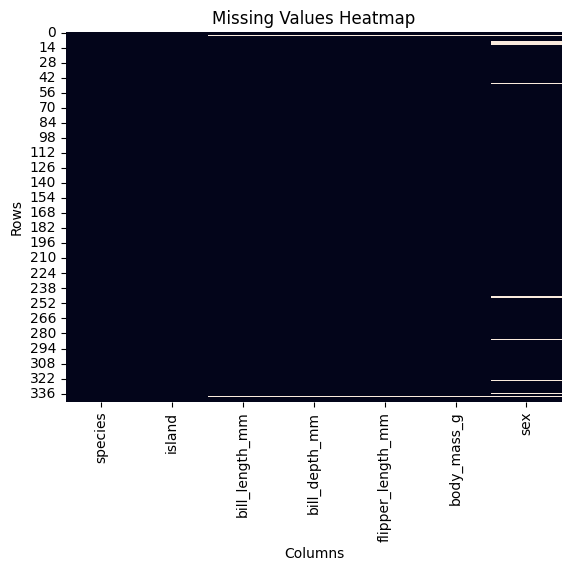

In [21]:
# YOUR CODE HERE (b)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

**Your answer:**

---
## Part B: Visualising Data (25 marks)

Every chart must have a **title**, an **x-axis label** and a **y-axis label**.

### Question 4: Histogram (8 marks)

Draw a histogram of `flipper_length_mm`.

a) Use 20 bins. **[3 marks]**

b) Add the x-axis label and the y-axis label. **[2 marks]**

c) Add a title. **[1 mark]**

d) Answer below: how many main peaks (high areas) do you see in the histogram? **[2 marks]**

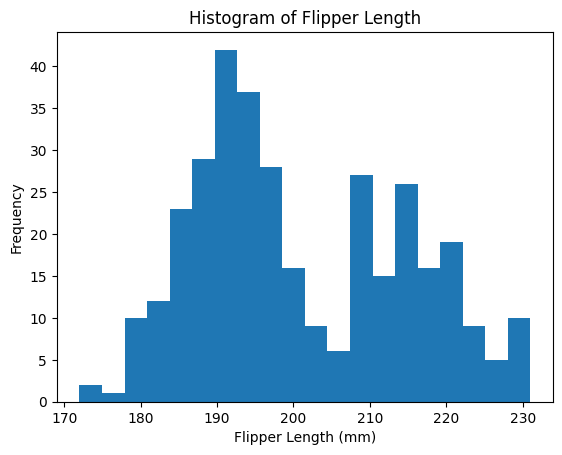

In [24]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

plt.hist(df["flipper_length_mm"].dropna(), bins=20)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Frequency")
plt.title("Histogram of Flipper Length")

plt.show()

#There are about 2 main peaks in the histogram.

**Your answer:**

### Question 5: Bar chart (8 marks)

Draw a bar chart that shows the **number of penguins on each island**.

a) Count the penguins on each island and draw the bars. *Hint: `value_counts()` then `plt.bar()`* **[3 marks]**

b) Add the title and both axis labels. **[2 marks]**

c) Write the count on top of each bar. *Hint: `plt.bar_label()`* **[3 marks]**

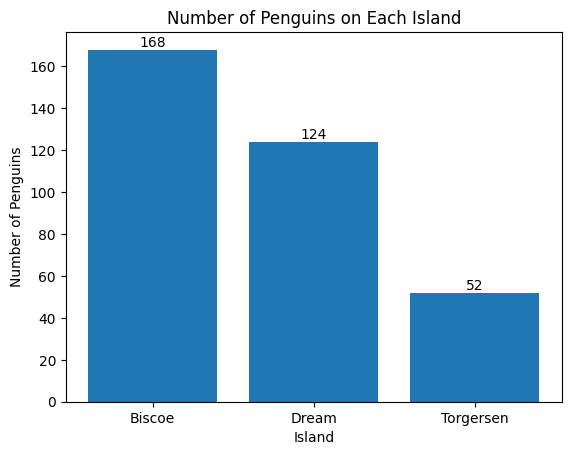

In [25]:
# YOUR CODE HERE
import matplotlib.pyplot as plt

island_counts = df["island"].value_counts()

plt.bar(island_counts.index, island_counts.values)

plt.title("Number of Penguins on Each Island")
plt.xlabel("Island")
plt.ylabel("Number of Penguins")

plt.bar_label(plt.gca().containers[0])

plt.show()

### Question 6: Scatter plot (9 marks)

a) Draw a scatter plot with `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis, with the dots coloured by `species`. *Hint: `sns.scatterplot(..., hue="species")`* **[4 marks]**

b) Add the title and both axis labels. **[2 marks]**

c) Answer below: can the three species be told apart using only these two measurements? Explain in one or two sentences. **[3 marks]**

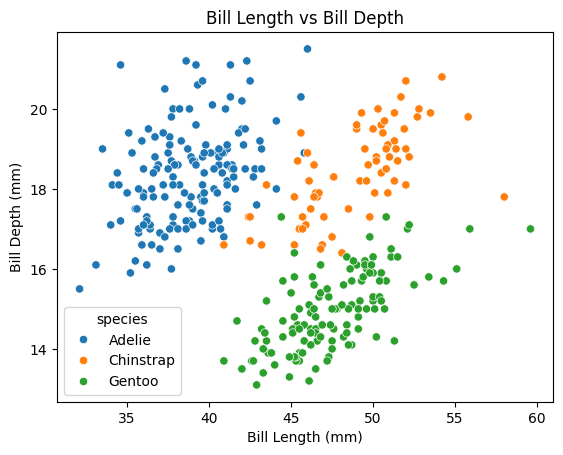

In [27]:
# YOUR CODE HERE
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species"
)

plt.title("Bill Length vs Bill Depth")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")

plt.show()

#No, the three species cannot be perfectly separated using only these two measurements. There is some overlap between the species, although they form different clusters.

**Your answer:**

---
## Part C: Cleaning and Preparing Data (45 marks)

### Question 7: Insert and remove columns (8 marks)

a) Add a new column `body_mass_kg` equal to `body_mass_g` divided by 1000. **[2 marks]**

b) Use `df.insert()` to add a column called `penguin_id` as the **first** column, with the numbers 1, 2, 3, ... up to the number of rows. **[3 marks]**

c) Remove the `body_mass_g` column, because `body_mass_kg` now holds the same information. Show the first 5 rows. **[3 marks]**

In [29]:
# YOUR CODE HERE
df["body_mass_kg"] = df["body_mass_g"] / 1000
df.insert(0, "penguin_id", range(1, len(df) + 1))
df.drop("body_mass_g", axis=1, inplace=True)

df.head()

,penguin_id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,sex,body_mass_kg
0,1,Adelie,Torgersen,39.1,18.7,181.0,MALE,3.75
1,2,Adelie,Torgersen,39.5,17.4,186.0,FEMALE,3.80
2,3,Adelie,Torgersen,40.3,18.0,195.0,FEMALE,3.25
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,5,Adelie,Torgersen,36.7,19.3,193.0,FEMALE,3.45


### Question 8: Fill missing values (10 marks)

a) Fill the missing values in the four numeric columns (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_kg`) with the **median** of each column. Use one line for each column. **[4 marks]**

b) Fill the missing values in `sex` with the **mode** (most frequent value). **[2 marks]**

c) Show that no missing values are left, with numbers. **[2 marks]**

d) Draw the missing-values heatmap again to show that no yellow is left. **[2 marks]**

In [32]:
# YOUR CODE HERE (a) and (b)
df["bill_length_mm"] = df["bill_length_mm"].fillna(df["bill_length_mm"].median())
df["bill_depth_mm"] = df["bill_depth_mm"].fillna(df["bill_depth_mm"].median())
df["flipper_length_mm"] = df["flipper_length_mm"].fillna(df["flipper_length_mm"].median())
df["body_mass_kg"] = df["body_mass_kg"].fillna(df["body_mass_kg"].median())

df["sex"] = df["sex"].fillna(df["sex"].mode()[0])

In [33]:
# YOUR CODE HERE (c)
df.isnull().sum()

,0
penguin_id,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
sex,0
body_mass_kg,0


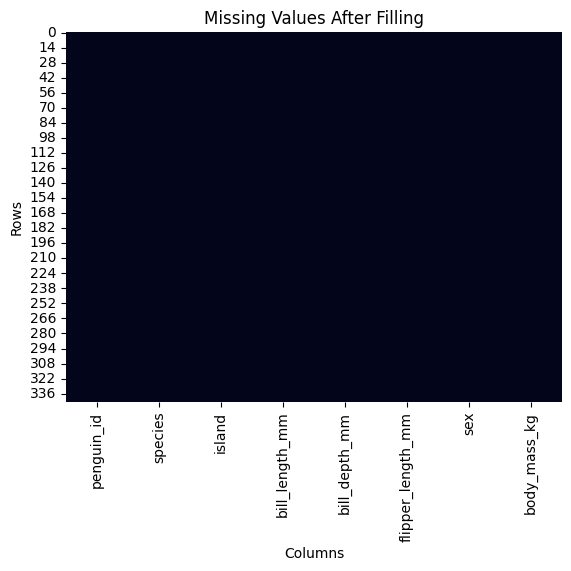

In [34]:
# YOUR CODE HERE (d)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values After Filling")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

### Question 9: Label the output column (9 marks)

a) Create `X` with all columns **except** `species` and `penguin_id`. Create `y` with only the `species` column. **[3 marks]**

b) The output is text. Use `map()` to turn it into numbers: Adelie = 0, Chinstrap = 1, Gentoo = 2. Store the result back in `y`. **[4 marks]**

c) Count how many times each number appears in `y`. The counts should match your answer to Question 2(c). **[2 marks]**

In [36]:
# YOUR CODE HERE

X = df.drop(columns=["species", "penguin_id"])
y = df["species"]

y = y.map({"Adelie": 0, "Chinstrap": 1, "Gentoo": 2})

y.value_counts()


,count
species,
0,152
2,124
1,68


### Question 10: Encode categorical values (9 marks)

a) Turn the `sex` column of `X` into numbers: MALE = 0, FEMALE = 1. **[3 marks]**

b) Use one-hot encoding on the `island` column of `X`, with 0 and 1 values. *Hint: `pd.get_dummies(X, columns=[...], dtype=int)`* **[4 marks]**

c) Show the first 5 rows of `X` and answer below: how many columns does `X` have now? **[2 marks]**

In [43]:
# YOUR CODE HERE
X['sex'] = X['sex'].map({"male": 0, "female": 1})
X.head()

pd.get_dummies(X, columns=['island'], dtype=int)
print(X.head())

      island  bill_length_mm  bill_depth_mm  flipper_length_mm  sex  \
0  Torgersen           39.10           18.7              181.0  NaN   
1  Torgersen           39.50           17.4              186.0  NaN   
2  Torgersen           40.30           18.0              195.0  NaN   
3  Torgersen           44.45           17.3              197.0  NaN   
4  Torgersen           36.70           19.3              193.0  NaN   

   body_mass_kg  
0          3.75  
1          3.80  
2          3.25  
3          4.05  
4          3.45  
